In [1]:
#!/usr/bin/env python
"""
ame_ground_ground_fit.py

Draws posterior samples from 15272-Cs and 15672-Cs MCMC chains, simulates
the ground→ground pure-rotational spectrum (axis a and axis b) with PGOPHER
for each sample, applies tunable post-simulation broadening, averages the
spectra over samples, then fits a NNLS linear combination of the four mean
profiles (15272-a, 15272-b, 15672-a, 15672-b) to Planck AME data.

Posterior selection follows the same burn-in / finite-mask pattern as
emcee_analysis_joint_with_geometry_plots_update_units_update_alpha.ipynb.

Usage
-----
python ame_ground_ground_fit.py \
    --file_15272 /scratch/.../15272_..._Cs_....h5 \
    --file_15672 /scratch/.../15672_..._Cs_....h5 \
    --n_samples 20 \
    --gauss_broad_MHz 3000 \
    --lorentz_broad_MHz 0 \
    --savefig figs/ame_gg_fit.png

If --file_15272 / --file_15672 are omitted the script auto-selects the most
recently modified matching HDF5 in --scratch_dir.
"""

import argparse, glob, os, shutil, subprocess
import numpy as np
import emcee
from pathlib import Path
from scipy.optimize import nnls
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

REPO_ROOT      = os.path.expanduser('~/DIB/')
PGO_TEMPLATE   = os.path.join(REPO_ROOT , 'pgo_files/ground_ground.pgo')
PGO_BIN        = os.path.join(REPO_ROOT , 'pgo')
SCRATCH_DEFAULT = os.path.expanduser('~/../../scratch/gpfs/MELCHIOR/cj1223/DIB')
BURNIN_MULT    = 5   # discard first BURNIN_MULT * max(tau) steps
exp = 1

# ── Planck 2011 AME data (from Planck 2011 XI, Table 1) ──────────────────────
AME_DATASETS = {
    'Perseus Cloud': dict(
        nu=np.array([
            0.408, 0.82, 1.42, 10.9, 12.7, 14.7, 16.3, 22.8, 28.5, 33.0,
            40.9, 44.1, 61.3, 70.3, 93.8, 100, 143, 217, 353, 545, 857,
            1250, 2143, 2997
        ]),
        flux=np.array([
            0.2, 0.5, -0.5, 9.4, 13.3, 21.8, 29.3, 33.4, 31.5, 29.7,
            22.6, 19.6, 10.9, 8.9, 7, 10, -25, 120, -600, -800, -1000,
            -2400, 7000, -2000
        ]),
        err=np.array([
            3.4, 4.8, 1.8, 2.0, 2.4, 3.3, 4.2, 4.5, 4.4, 4.4,
            4.0, 4.0, 6.4, 9.0, 21, 29, 80, 320, 1400, 4900, 14000,
            28000, 35000, 20000
        ]),
    ),
    r'$\rho$ Ophiuchi Cloud': dict(
        nu=np.array([
            0.4, 1.4, 2.3, 22.7, 28.5, 33.0, 40.7, 44.1, 60.6, 70.3,
            93.4, 100, 143, 217, 353, 545, 857, 1249, 2141, 2997
        ]),
        flux=np.array([
            -7, -1.0, 1.2, 24.8, 27.3, 27.2, 21.9, 19.9, 9.8, 6.5,
            6, 13, 5, 130, -180, 400, 500, -5000, 20000, -9000
        ]),
        err=np.array([
            11, 8.3, 8.3, 6.6, 6.6, 6.3, 5.8, 5.7, 6.5, 7.8,
            15, 19, 49, 200, 780, 3200, 10000, 25000, 41000, 32000
        ]),
    ),
}


# ─────────────────────────────────────────────────────────────────────────────
def parse_args():
    p = argparse.ArgumentParser(description=__doc__,
                                formatter_class=argparse.RawDescriptionHelpFormatter)
    p.add_argument('--file_15272', default=None,
                   help='HDF5 backend for 15272 Cs (auto-selected if omitted)')
    p.add_argument('--file_15672', default=None,
                   help='HDF5 backend for 15672 Cs (auto-selected if omitted)')
    p.add_argument('--scratch_dir', default=SCRATCH_DEFAULT,
                   help='Scratch directory for auto-detection of backend files')
    p.add_argument('--n_samples', type=int, default=20,
                   help='Number of posterior samples per DIB (default 20)')
    p.add_argument('--gauss_broad_MHz', type=float, default=3000.0,
                   help='Additional Gaussian broadening FWHM [MHz] applied after simulation (default 3000)')
    p.add_argument('--lorentz_broad_MHz', type=float, default=0.0,
                   help='Additional Lorentzian broadening FWHM [MHz] applied after simulation (default 0)')
    p.add_argument('--seed', type=int, default=42)
    p.add_argument('--savefig', default=str(REPO_ROOT / 'figs' / 'ame_gg_fit.png'),
                   help='Output figure path')
    p.add_argument('--save_spectra', default=None,
                   help='If set, save mean spectra to this .npz path for inspection')
    return p.parse_args()


# ─────────────────────────────────────────────────────────────────────────────
def find_backend(scratch_dir, dib, sym='Cs'):
    pattern = os.path.join(os.path.expanduser(scratch_dir), '*.h5')
    matches = [
        f for f in glob.glob(pattern)
        if f'{dib}_run_' in os.path.basename(f)
        and f'Symmetry{sym}' in os.path.basename(f)
        and 'temppy' not in os.path.basename(f)
    ]
    if not matches:
        raise FileNotFoundError(f'No {dib} Cs backend found in {scratch_dir}')
    best = sorted(matches, key=os.path.getmtime, reverse=True)[0]
    return best


def load_flat_samples(h5_path):
    h5_path = os.path.expanduser(h5_path)
    backend  = emcee.backends.HDFBackend(h5_path, read_only=True)
    chain    = backend.get_chain()       # (nsteps, nwalkers, ndim)
    log_prob = backend.get_log_prob()    # (nsteps, nwalkers)

    tau     = emcee.autocorr.integrated_time(chain, tol=0)
    burnin  = int(BURNIN_MULT * np.max(tau))
    burnin  = max(1, min(burnin, chain.shape[0] - 1))

    flat_samples  = chain[burnin:].reshape(-1, chain.shape[2])
    flat_log_prob = log_prob[burnin:].reshape(-1)

    finite_mask  = np.isfinite(flat_log_prob)
    flat_samples = flat_samples[finite_mask]

    print(f'    burn-in: {burnin} steps  (= {BURNIN_MULT} × max(τ) = {BURNIN_MULT:.0f} × {np.max(tau):.1f})')
    print(f'    flat samples available: {len(flat_samples)}')
    return flat_samples


# ─────────────────────────────────────────────────────────────────────────────
def _run_pgopher(T, A, B, C, axis, temp_dir):
    """Run PGOPHER for the ground→ground rotational spectrum.

    Returns (freq_MHz, intensity) as 1-D numpy arrays on the native grid.
    """
    tag      = f'T{T:.4f}_A{A:.7f}_B{B:.7f}_C{C:.7f}_ax{axis}'
    pgo_file = os.path.join(temp_dir, f'gg_{tag}.pgo')
    spec_txt = os.path.join(temp_dir, f'gg_{tag}.txt')

    # Patch the template: Temperature, A, B, C, and transition-moment axis.
    # The ground_ground.pgo has a single manifold so no inside/outside-manifold
    # guards are needed — just match the parameter names directly.
    awk = f"""awk \\
  -v temp="{T}" \\
  -v A_val="{A}" -v B_val="{B}" -v C_val="{C}" \\
  -v axis="{axis}" '
/<Parameter Name="Temperature" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<Parameter Name="A" Value=/           {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_val "\\"") }}
/<Parameter Name="B" Value=/           {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_val "\\"") }}
/<Parameter Name="C" Value=/           {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_val "\\"") }}
/<CartesianTransitionMoment Axis=/     {{ sub(/Axis="[^"]+"/, "Axis=\\"" axis "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}"""

    subprocess.run(awk, shell=True, check=True, executable='/bin/bash')
    subprocess.run([PGO_BIN, '--plot', pgo_file, spec_txt],
                   check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    data = np.loadtxt(spec_txt)
    os.remove(pgo_file)
    os.remove(spec_txt)

    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data[:, 0].copy(), data[:, 1].copy()   # freq_MHz, intensity


def simulate_raw(flat_samples, n_samples, dib_label, axes, temp_dir, rng):
    """Draw n_samples from flat_samples and run PGOPHER for each (sample, axis).

    Returns the raw, unbroadened spectra stacked into arrays so that
    broadening can be applied (and re-applied) separately without re-simulating.

    Cs parameter vector (B_not_equal_C=True):
      [T, A, B, C, frac_A, frac_B, frac_C, lorentz_width, (center_offset)]
    B_not_equal_C=False:
      [T, A, C, frac_A, frac_C, lorentz_width, ...]  where B = C

    Returns
    -------
    freq_MHz   : 1-D array — common frequency grid from PGOPHER [MHz]
    raw_stacks : dict[axis -> ndarray (n_valid_samples, n_freq)]
    """
    n_avail = len(flat_samples)
    if n_samples > n_avail:
        print(f'  Warning: requested {n_samples} but only {n_avail} available; using all.')
        n_samples = n_avail
    idx     = rng.choice(n_avail, size=n_samples, replace=False)
    samples = flat_samples[idx]

    ndim    = samples.shape[1]
    b_neq_c = (ndim >= 8)

    freq_ref = None
    stacks   = {ax: [] for ax in axes}

    for i, s in enumerate(samples):
        T = s[0]; A = s[1]
        if b_neq_c:
            B, C = s[2], s[3]
        else:
            C = s[2]; B = C

        print(f'  [{dib_label}] sample {i+1:3d}/{n_samples}: '
              f'T={T:.1f} K  A={A:.5f}  B={B:.5f}  C={C:.5f}', flush=True)

        for ax in axes:
            try:
                freq, spec = _run_pgopher(T, A, B, C, ax, temp_dir)
                if freq_ref is None:
                    freq_ref = freq
                stacks[ax].append(np.interp(freq_ref, freq, spec, left=0.0, right=0.0))
            except Exception as e:
                print(f'    ERROR [{dib_label}] axis={ax} sample {i+1}: {e}', flush=True)

    n_freq     = len(freq_ref) if freq_ref is not None else 1
    raw_stacks = {ax: (np.array(stacks[ax]) if stacks[ax] else np.zeros((0, n_freq)))
                  for ax in axes}
    return freq_ref, raw_stacks


def apply_broadening_log(freq_MHz, raw_stacks, gauss_dex=0.0, lorentz_dex=0.0,
                         nu_min_MHz=100.0):
    """Average raw spectrum stacks and apply broadening in log-frequency space.

    Broadening on a log10(ν) grid gives a kernel whose absolute MHz width
    scales with frequency, extending more evenly across the full dynamic range
    and with a longer tail toward lower frequencies than a fixed-MHz kernel.

    Parameters
    ----------
    freq_MHz    : 1-D array — native linear frequency grid [MHz]
    raw_stacks  : dict[axis -> (n_samples, n_freq)] from simulate_raw
    gauss_dex   : Gaussian FWHM in dex of log10(ν)  (0 = disabled)
    lorentz_dex : Lorentzian FWHM in dex of log10(ν) (0 = disabled)
    nu_min_MHz  : lower cutoff for the log grid [MHz]; region below is zeroed

    Returns
    -------
    freq_MHz     : same input array (unchanged)
    mean_spectra : dict[axis -> broadened mean spectrum on freq_MHz grid]
    """
    nu_min   = max(nu_min_MHz, freq_MHz[freq_MHz > 0].min())
    nu_max   = freq_MHz.max()
    n_log    = len(freq_MHz)
    log_grid = np.linspace(np.log10(nu_min), np.log10(nu_max), n_log)
    dlog     = log_grid[1] - log_grid[0]
    freq_log = 10.0 ** log_grid   # [MHz]

    def _convolve_log(spec_log):
        out = spec_log.copy()
        if gauss_dex > 0:
            sigma = gauss_dex / (2.0 * np.sqrt(2.0 * np.log(2.0)))
            hw    = int(np.ceil(5.0 * sigma / dlog))
            t     = np.arange(-hw, hw + 1) * dlog
            kern  = np.exp(-t**2 / (2.0 * sigma**2))
            kern /= kern.sum()
            out   = fftconvolve(out, kern, mode='same')
        if lorentz_dex > 0:
            gamma = lorentz_dex / 2.0
            hw    = int(np.ceil(20.0 * gamma / dlog))
            t     = np.arange(-hw, hw + 1) * dlog
            kern  = (gamma / np.pi) / (t**2 + gamma**2)
            kern /= kern.sum()
            out   = fftconvolve(out, kern, mode='same')
        return out

    mean_spectra = {}
    for ax, stack in raw_stacks.items():
        if stack.shape[0] == 0:
            mean_spectra[ax] = np.zeros_like(freq_MHz)
            continue
        mean_lin        = stack.mean(axis=0)
        spec_log        = np.interp(freq_log, freq_MHz, mean_lin, left=0.0, right=0.0)
        spec_log_broad  = _convolve_log(spec_log)
        mean_spectra[ax] = np.interp(freq_MHz, freq_log, spec_log_broad, left=0.0, right=0.0)

    return freq_MHz, mean_spectra


# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
def fit_shared_ratios(profiles_GHz, profile_labels, datasets,
                      fit_mode='nnls', neg_reg=0.0):
    """Fit both AME datasets jointly with the a/b axis amplitude ratio shared
    across clouds for each DIB molecule.

    Model per dataset:
        F(ν) = A_1272 * (r1 * P_1272a + P_1272b) + A_1672 * (r2 * P_1672a + P_1672b)

    r1, r2 are shared; A_1272 and A_1672 are fitted independently per dataset.

    Returns
    -------
    r1, r2 : optimal a/b ratios for 15272 and 15672
    results : same dict format as fit_nnls / fit_free output — 4-element amps
              [A_1272*r1, A_1272, A_1672*r2, A_1672] per dataset for plot_results
    """
    from scipy.optimize import minimize

    def _find(dib, axis):
        return next(j for j, l in enumerate(profile_labels)
                    if dib in l and f'{axis}-axis' in l)
    ia1, ib1 = _find('15272', 'a'), _find('15272', 'b')
    ia2, ib2 = _find('15672', 'a'), _find('15672', 'b')

    ds_names = list(datasets.keys())
    ds_list  = list(datasets.values())

    def _norm(j, nu_arr):
        freq_GHz, spec = profiles_GHz[j]
        peak = np.max(np.abs(spec))
        if peak == 0:
            return np.zeros(len(nu_arr))
        return nu_arr * np.interp(nu_arr, freq_GHz, spec / peak, left=0., right=0.)

    profs = [{'Pa1': _norm(ia1, ds['nu']), 'Pb1': _norm(ib1, ds['nu']),
              'Pa2': _norm(ia2, ds['nu']), 'Pb2': _norm(ib2, ds['nu'])}
             for ds in ds_list]

    def _inner(ds, p, r1, r2):
        """Given r1, r2 fit the two overall amplitudes for one dataset."""
        Q1 = r1 * p['Pa1'] + p['Pb1']
        Q2 = r2 * p['Pa2'] + p['Pb2']
        M  = np.column_stack([Q1, Q2])
        Mw = M / ds['err'][:, None]
        fw = ds['flux'] / ds['err']
        if fit_mode == 'nnls':
            amps_inner, _ = nnls(Mw, fw)
        else:
            # Unconstrained start
            amps_inner, _, _, _ = np.linalg.lstsq(Mw, fw, rcond=None)
            if neg_reg > 0:
                # Iterative reweighted lstsq: apply sqrt(neg_reg) penalty
                # only to currently-negative amplitudes, iterate to convergence.
                for _ in range(30):
                    w = np.where(amps_inner < 0, np.sqrt(neg_reg), 0.0)
                    if w.max() == 0:
                        break
                    M_aug = np.vstack([Mw, np.diag(w)])
                    fw_aug = np.concatenate([fw, np.zeros(len(amps_inner))])
                    prev = amps_inner.copy()
                    amps_inner, _, _, _ = np.linalg.lstsq(M_aug, fw_aug, rcond=None)
                    if np.max(np.abs(amps_inner - prev)) < 1e-12:
                        break
        resid = ds['flux'] - M @ amps_inner
        chi2  = float(np.sum((resid / ds['err']) ** 2))
        return amps_inner, chi2

    def total_chi2(params):
        r1, r2 = (np.exp(params) if fit_mode == 'nnls' else params)
        return sum(_inner(ds, p, r1, r2)[1] for ds, p in zip(ds_list, profs))

    x0  = [0., 0.] if fit_mode == 'nnls' else [1., 1.]
    res = minimize(total_chi2, x0, method='Nelder-Mead',
                   options={'xatol': 1e-7, 'fatol': 1e-7, 'maxiter': 20000})
    r1, r2 = (np.exp(res.x) if fit_mode == 'nnls' else res.x)

    results = {}
    for ds, p, name in zip(ds_list, profs, ds_names):
        (A1272, A1672), chi2 = _inner(ds, p, r1, r2)
        full_amps = np.array([A1272 * r1, A1272, A1672 * r2, A1672])
        results[name] = dict(
            nu=ds['nu'], flux=ds['flux'], err=ds['err'],
            amps=full_amps, chi2=chi2,
            M_data=build_model_matrix(profiles_GHz, ds['nu'])
        )

    return r1, r2, results


def build_model_matrix(profiles_GHz, nu_data_GHz):
    """Evaluate each mean profile at the AME data frequencies (GHz).

    profiles_GHz : list of (freq_GHz, mean_spec) tuples, one per template
    nu_data_GHz  : 1-D array of AME data frequencies [GHz]

    Returns (N_data × N_profiles) design matrix, normalised so each column
    peaks at 1 (same convention as AME_plot.ipynb).
    """
    M = np.zeros((len(nu_data_GHz), len(profiles_GHz)))
    for j, (freq_GHz, spec) in enumerate(profiles_GHz):
        peak = np.max(np.abs(spec))
        if peak == 0:
            continue
        spec_norm = spec / peak
        M[:, j]   = (nu_data_GHz)**exp * np.interp(nu_data_GHz, freq_GHz, spec_norm, left=0.0, right=0.0)
    return M


def fit_nnls(M, flux, err):
    """Non-negative least squares (amplitudes >= 0)."""
    Mw    = M    / err[:, None]
    fw    = flux / err
    amps, _ = nnls(Mw, fw)
    residuals = flux - M @ amps
    chi2 = np.sum((residuals / err)**2)
    return amps, chi2


def fit_free(M, flux, err, neg_reg=0.0):
    """Unconstrained weighted least squares (amplitudes may be negative).

    neg_reg > 0 adds a one-sided quadratic penalty neg_reg * sum(min(0, amp)^2)
    to the objective, softly discouraging large negative amplitudes.
    """
    from scipy.optimize import minimize
    Mw = M / err[:, None]
    fw = flux / err
    if neg_reg <= 0:
        amps, _, _, _ = np.linalg.lstsq(Mw, fw, rcond=None)
    else:
        def objective(a):
            r = Mw @ a - fw
            return float(np.dot(r, r) + neg_reg * np.sum(np.minimum(a, 0.0) ** 2))
        a0, _, _, _ = np.linalg.lstsq(Mw, fw, rcond=None)
        result = minimize(objective, a0, method='L-BFGS-B')
        amps = result.x
    residuals = flux - M @ amps
    chi2 = np.sum((residuals / err) ** 2)
    return amps, chi2


# ─────────────────────────────────────────────────────────────────────────────
def plot_results(profiles_GHz, profile_labels, results, savefig, fit_mode='nnls'):
#     mpl.rcParams.update(mpl.rcParamsDefault)
#     plt.rcParams['figure.facecolor'] = 'white'
#     plt.rc('font', family='serif', size=13)
#     plt.rc('axes', linewidth=1.5)
#     plt.rc('xtick', labelsize=13, direction='in', top=True)
#     plt.rc('ytick', labelsize=13, direction='in', right=True)
#     plt.rc('xtick.minor', visible=True)
#     plt.rc('ytick.minor', visible=True)

    colors = ['tomato', 'firebrick', 'cornflowerblue', 'steelblue']
    ls_map = ['-', '--', '-', '--']
    nu_fine = np.logspace(np.log10(0.3), np.log10(200), 3000)

    n_ds = len(results)
    fig, axes = plt.subplots(2, n_ds, figsize=(10 * n_ds, 7), sharex=True,
                             gridspec_kw={'height_ratios': [6, 1], 'hspace': 0.0,
                                          'wspace': 0.22})
    if n_ds == 1:
        axes = axes[:, np.newaxis]

    for col, (ds_name, ds) in enumerate(results.items()):
        ax_top = axes[0, col]
        ax_res = axes[1, col]
        nu      = ds['nu']
        flux    = ds['flux']
        err     = ds['err']
        amps    = ds['amps']
        chi2    = ds['chi2']
        M_data  = ds['M_data']
        flux_model_at_data = M_data @ amps

        # Fine-grid model
        M_fine     = build_model_matrix(profiles_GHz, nu_fine)
        flux_model = M_fine @ amps

        dof = int(np.sum(np.logical_and(flux > 0,
                                        np.logical_and(nu > 5, nu < 200)))) \
              - int(np.sum(amps > 0.1))
        dof = max(dof, 1)

        ax_top.errorbar(nu, flux, yerr=err, fmt='o', color='k',
                        label='Data (Planck 2011)', ms=5, zorder=5)
        ax_top.plot(nu_fine, flux_model, c='purple', lw=2, label='Total fit')

        if fit_mode == 'nnls':
            for j, (label, (freq_GHz, spec)) in enumerate(zip(profile_labels, profiles_GHz)):
                if amps[j] < 1e-1:
                    continue
                peak = np.max(np.abs(spec))
                if peak == 0:
                    continue
                spec_fine = (nu_fine)**(exp) * np.interp(nu_fine, freq_GHz, spec / peak, left=0.0, right=0.0)
                ax_top.fill_between(nu_fine, amps[j] * spec_fine, alpha=0.3,
                                    color=colors[j], label=label, linestyle=ls_map[j])
        else:
            # Free/shared fit: shade total 15272 (red) and 15672 (blue) contributions
            y_floor = 1e-5   # below ylim; avoids log(0) in fill_between
            dib_groups = {
                '15272': ('tomato',        [j for j, l in enumerate(profile_labels) if '15272' in l]),
                '15672': ('cornflowerblue',[j for j, l in enumerate(profile_labels) if '15672' in l]),
            }
            for dib_name, (color, idxs) in dib_groups.items():
                total = sum(
                    amps[j] * nu_fine**(exp) * np.interp(nu_fine, profiles_GHz[j][0],
                                        profiles_GHz[j][1] / max(np.max(np.abs(profiles_GHz[j][1])), 1e-30),
                                        left=0.0, right=0.0)
                    for j in idxs
                )
                total_clipped = np.maximum(total, y_floor)
                ax_top.fill_between(nu_fine, y_floor, total_clipped, alpha=0.3,
                                    color=color, label=f'{dib_name} total (a+b)', zorder=3)
                ax_top.plot(nu_fine, total_clipped, color=color, lw=1.5, zorder=4)

        ax_top.set_xscale('log')
        ax_top.set_yscale('log')
        ax_top.set_xlim(5, 200)
        ax_top.set_ylim(0.4, 50)
        ax_top.set_ylabel('Flux (Jy)')
        ax_top.set_title(ds_name)
#         ax_top.legend(fontsize=10, ncol=2, loc='lower left', framealpha=0.9)
        
        handles, lbls = ax_top.get_legend_handles_labels()
        if len(handles) == 2:
            order   = [1,0]
        if len(handles) == 4:
            order   = [3,1,0,2]
        if len(handles) == 5:
            order   = [4, 2, 3, 0, 1]
        if len(handles) == 6:
            order   = [5, 1, 2, 0, 3, 4]
        print(len(handles))
        handles = [handles[i] for i in order]
        lbls    = [lbls[i]    for i in order]
        ax_top.legend(handles, lbls, fontsize=12, ncol=2, loc='lower left', columnspacing=0.6, framealpha = 0.9)

        
        ax_top.text(0.03, 0.97,
                    rf'$\chi^2 = {chi2:.1f}$' + '\n'
                    rf'dof $= {dof}$' + '\n'
                    rf'$\chi^2_\nu = {chi2/dof:.1f}$',
                    transform=ax_top.transAxes, fontsize=12,
                    ha='left', va='top')

        ax_res.scatter(nu, (flux - flux_model_at_data) / err,
                       color='k', s=20, zorder=5)
        ax_res.axhline(0, color='gray', lw=1)
        ax_res.set_xlabel('Frequency (GHz)')
        ax_res.set_ylabel(r'$\chi$')
        f = 1.4
        m = np.max([np.max(np.abs(ax_res.get_ylim())), 1])
        ax_res.set_ylim(-m*f, m*f)


    plt.suptitle( "The Inferred Molecules Are Plausible Sources of the Anomalous Microwave Emission", y = 1.0, fontsize = 27)
    
    plt.tight_layout()
    if savefig:
        os.makedirs(os.path.dirname(os.path.abspath(savefig)), exist_ok=True)
        plt.savefig(savefig, dpi=200, bbox_inches='tight')
        print(f'\nFigure saved → {savefig}')
    plt.show()

In [ ]:
# ── Run once: load posteriors and simulate raw spectra ───────────────────────
seed      = 42
rng       = np.random.default_rng(seed)
n_samples = 10

file_15672 = SCRATCH_DEFAULT + '/' + '15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p075_alphaCutoffFalse_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,2p0,-2p0]_centeroffset0p1_restart_sym_alpha.h5'
file_15272 = SCRATCH_DEFAULT + '/' + '15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p025_alphaCutoffFalse_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,2p0,2p0]_centeroffset0p01_restart_sym_alpha.h5'

print(f'15272 backend: {os.path.basename(file_15272)}')
print(f'15672 backend: {os.path.basename(file_15672)}')

print('\nLoading 15272 Cs posterior...')
flat_15272 = load_flat_samples(file_15272)
print('Loading 15672 Cs posterior...')
flat_15672 = load_flat_samples(file_15672)

temp_dir = os.path.expanduser('~/../../scratch/gpfs/MELCHIOR/cj1223/DIB/pgo_temppy_ame_gg')
shutil.rmtree(temp_dir, ignore_errors=True)
os.makedirs(temp_dir)

axes = ['a', 'c']

print(f'\nSimulating 15272 ground\u2192ground ({n_samples} samples \u00d7 2 axes)...')
freq_MHz_15272, raw_stacks_15272 = simulate_raw(flat_15272, n_samples, '15272', axes, temp_dir, rng)

print(f'\nSimulating 15672 ground\u2192ground ({n_samples} samples \u00d7 2 axes)...')
freq_MHz_15672, raw_stacks_15672 = simulate_raw(flat_15672, n_samples, '15672', axes, temp_dir, rng)

shutil.rmtree(temp_dir, ignore_errors=True)
print('\nSimulations complete. Re-run the next cell to change broadening.')


15272 backend: 15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p025_alphaCutoffFalse_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,2p0,2p0]_centeroffset0p01_restart_sym_alpha.h5
15672 backend: 15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p075_alphaCutoffFalse_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,2p0,-2p0]_centeroffset0p1_restart_sym_alpha.h5

Loading 15272 Cs posterior...
    burn-in: 1114 steps  (= 5 × max(τ) = 5 × 222.9)
    flat samples available: 239616
Loading 15672 Cs posterior...
    burn-in: 1991 steps  (= 5 × max(τ) = 5 × 398.4)
    flat samples available: 192576

Simulating 15272 ground→ground (10 samples × 2 axes)...
  [15272] sample   1/10: T=5.4 K  A=0.04627  B=0.00253  C=0.00234
  [15272] sample   2/10: T=7.9 K  A=0.03395  B=0.00331  C=0.00325
  [15272] sample   3/10: T=11.3 K  A=0.02271  B=0.00208  C=0.00109
  [15

In [ ]:
# ── Re-runnable: apply broadening, fit, plot ─────────────────────────────────
# Change any option below and re-run this cell — no re-simulation needed.
gauss_dex   = 0.02    # Gaussian FWHM in dex of log10(freq_MHz)
lorentz_dex = 0.02    # Lorentzian FWHM in dex of log10(freq_MHz)
fit_mode    = 'nnls' # 'nnls' = non-negative amplitudes; 'free' = unconstrained chi^2
neg_reg     = 0.2  # one-sided penalty on negative amplitudes (free mode only; 0 = disabled)
savefig     = False

_fit_fn = fit_nnls if fit_mode == 'nnls' else (lambda M, f, e: fit_free(M, f, e, neg_reg))

_, specs_15272 = apply_broadening_log(freq_MHz_15272, raw_stacks_15272, gauss_dex, lorentz_dex)
_, specs_15672 = apply_broadening_log(freq_MHz_15672, raw_stacks_15672, gauss_dex, lorentz_dex)

freq_GHz_15272 = freq_MHz_15272 / 1000.0
freq_GHz_15672 = freq_MHz_15672 / 1000.0

profiles_GHz = [
    (freq_GHz_15272, specs_15272['a']),
    (freq_GHz_15272, specs_15272['c']),
    (freq_GHz_15672, specs_15672['a']),
    (freq_GHz_15672, specs_15672['c']),
]
profile_labels = ['15272  a-axis', '15272  b-axis', '15672  a-axis', '15672  b-axis']

print('\nFitting NNLS to AME data...')
results = {}
for ds_name, ds in AME_DATASETS.items():
    M_data = build_model_matrix(profiles_GHz, ds['nu'])
    amps, chi2 = _fit_fn(M_data, ds['flux'], ds['err'])
    results[ds_name] = dict(nu=ds['nu'], flux=ds['flux'], err=ds['err'],
                            amps=amps, chi2=chi2, M_data=M_data)
    print(f'\n  {ds_name}')
    print(f'  {"Profile":<20} {"Amplitude":>10}')
    print('  ' + '-' * 32)
    for lbl, amp in zip(profile_labels, amps):
        print(f'  {lbl:<20} {amp:10.3f}')
    print(f'  chi2 = {chi2:.2f}')

plot_results(profiles_GHz, profile_labels, results, savefig, fit_mode=fit_mode)


In [ ]:
# ── Constrained fit: shared a/b ratio across both clouds ─────────────────────
# r1 = 15272 a/b amplitude ratio, r2 = 15672 a/b — both shared across datasets.
fit_mode_shared = 'nnls'  # 'nnls' or 'free'
neg_reg_shared  = 0  # one-sided neg penalty (free mode only)

r1, r2, shared_results = fit_shared_ratios(
    profiles_GHz, profile_labels, AME_DATASETS,
    fit_mode=fit_mode_shared, neg_reg=neg_reg_shared)

print(f'Optimal shared ratios:')
print(f'  15272  a/b = {r1:.3f}')
print(f'  15672  a/b = {r2:.3f}')
for ds_name, ds in shared_results.items():
    amps = ds['amps']
    print(f'\n  {ds_name}:  chi2 = {ds["chi2"]:.2f}')
    print(f'    A_15272 = {amps[1]:.3f}   (a-amp = {amps[0]:.3f})')
    print(f'    A_15672 = {amps[3]:.3f}   (a-amp = {amps[2]:.3f})')

plot_results(profiles_GHz, profile_labels, shared_results,
             savefig='../../figs/AME_pgopher.png', fit_mode='free')


Pre-broadening 15272 samples...
Pre-broadening 15672 samples...

Grid search over 10 x 10 = 100 pairs...
Best pair: 15272 sample 4,  15672 sample 0
Best chi2 = 9.18   mean = 30.40   worst = 93.95
4
5


/tmp/ipykernel_2939043/314624218.py:554: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


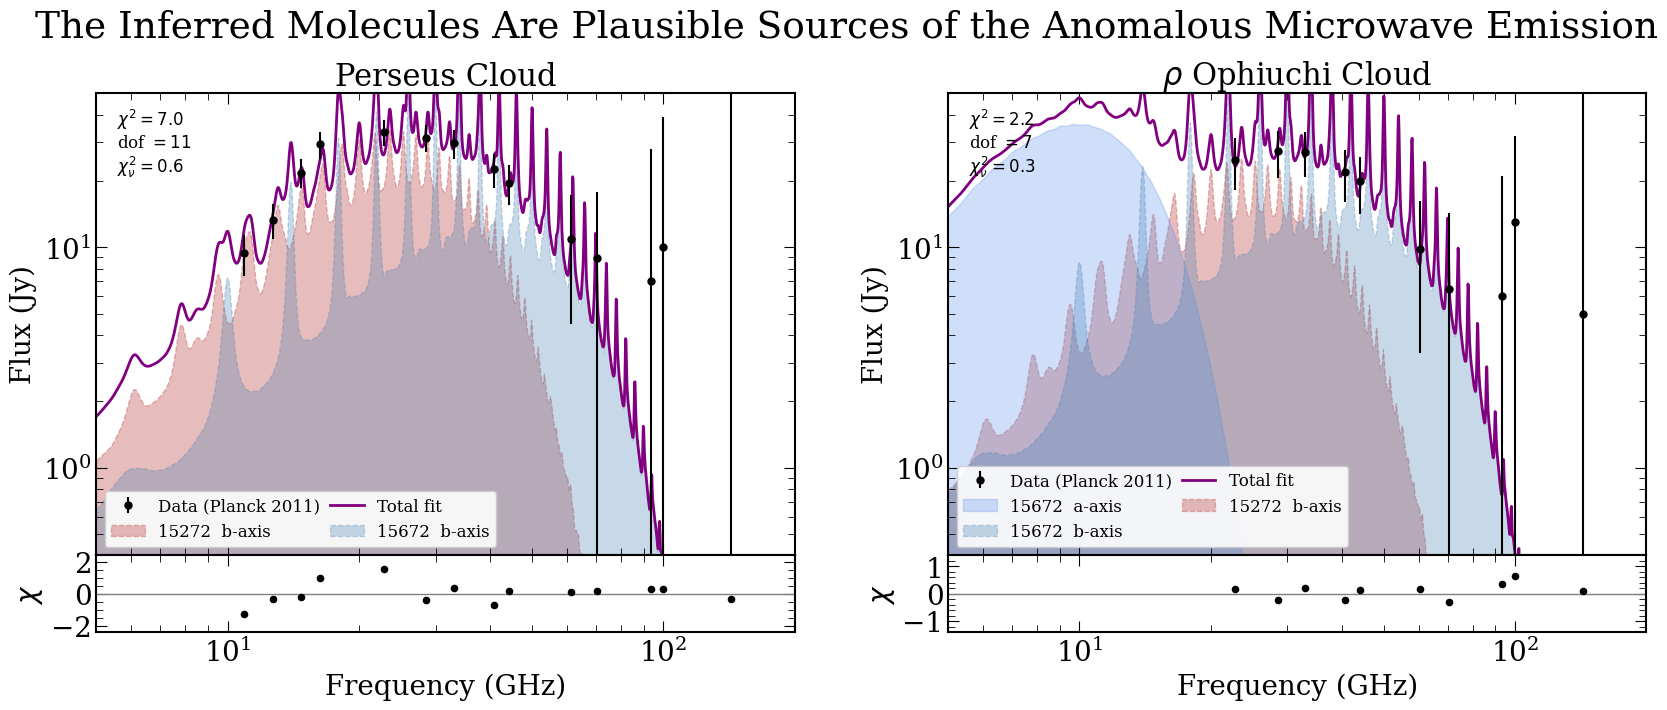

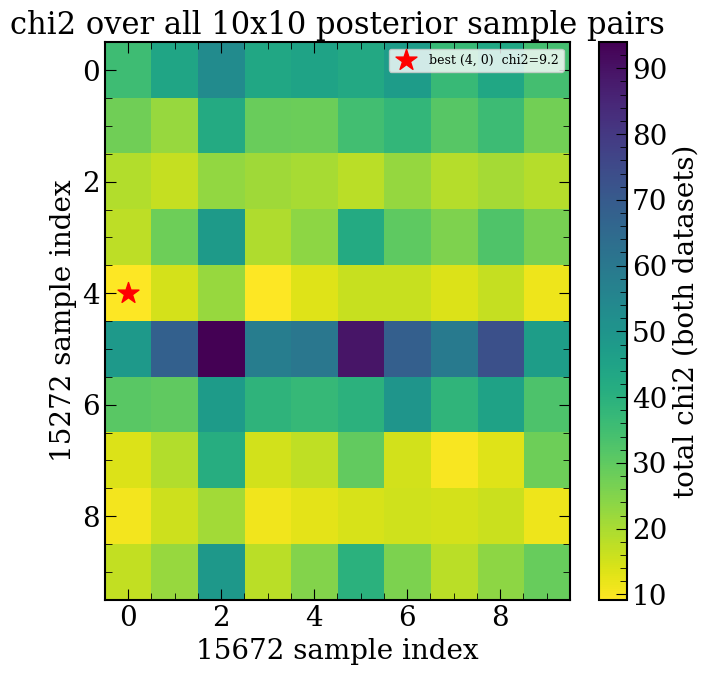

In [45]:
# ── Best posterior sample pair ───────────────────────────────────────────────
# Evaluates every (i_15272, j_15672) combination of individual posterior
# samples and picks the pair that minimises chi2 across both AME datasets.
fit_mode_best = fit_mode    # inherit from cell 2; override here if needed
fit_mode_best = 'nnls'    # inherit from cell 2; override here if needed
neg_reg_best  = 0.5
_fit_fn_best  = fit_nnls if fit_mode_best == 'nnls' else (lambda M,f,e: fit_free(M,f,e,neg_reg_best))

gauss_dex, lorentz_dex = 0.001, 0.001

# Pre-broaden each individual sample once (avoids redundant convolutions)
def _prebroaden(raw_stacks, freq_MHz, axes):
    out = {}
    for ax in axes:
        stack = raw_stacks[ax]
        broad = np.zeros_like(stack)
        for k in range(stack.shape[0]):
            _, sp = apply_broadening_log(freq_MHz, {ax: stack[k:k+1]}, gauss_dex, lorentz_dex)
            broad[k] = sp[ax]
        out[ax] = broad
    return out

axes = ['a', 'c']
print("Pre-broadening 15272 samples...")
broad_1272 = _prebroaden(raw_stacks_15272, freq_MHz_15272, axes)
print("Pre-broadening 15672 samples...")
broad_1672 = _prebroaden(raw_stacks_15672, freq_MHz_15672, axes)

freq_GHz_1272 = freq_MHz_15272 / 1000.0
freq_GHz_1672 = freq_MHz_15672 / 1000.0

n1, n2 = broad_1272['a'].shape[0], broad_1672['a'].shape[0]
print(f"\nGrid search over {n1} x {n2} = {n1*n2} pairs...")
chi2_grid = np.full((n1, n2), np.nan)

for i in range(n1):
    for j in range(n2):
        profiles_ij = [
            (freq_GHz_1272, broad_1272['a'][i]),
            (freq_GHz_1272, broad_1272['c'][i]),
            (freq_GHz_1672, broad_1672['a'][j]),
            (freq_GHz_1672, broad_1672['c'][j]),
        ]
        total = 0.0
        for ds in AME_DATASETS.values():
            M = build_model_matrix(profiles_ij, ds['nu'])
            _, c2 = _fit_fn_best(M, ds['flux'], ds['err'])
            total += c2
        chi2_grid[i, j] = total

best_i, best_j = np.unravel_index(np.nanargmin(chi2_grid), chi2_grid.shape)
best_chi2 = chi2_grid[best_i, best_j]
print(f"Best pair: 15272 sample {best_i},  15672 sample {best_j}")
print(f"Best chi2 = {best_chi2:.2f}   mean = {np.nanmean(chi2_grid):.2f}   worst = {np.nanmax(chi2_grid):.2f}")

# Fit and plot the best combination
best_profiles = [
    (freq_GHz_1272, broad_1272['a'][best_i]),
    (freq_GHz_1272, broad_1272['c'][best_i]),
    (freq_GHz_1672, broad_1672['a'][best_j]),
    (freq_GHz_1672, broad_1672['c'][best_j]),
]
best_results = {}
for ds_name, ds in AME_DATASETS.items():
    M = build_model_matrix(best_profiles, ds['nu'])
    amps, chi2 = _fit_fn_best(M, ds['flux'], ds['err'])
    best_results[ds_name] = dict(nu=ds['nu'], flux=ds['flux'], err=ds['err'],
                                 amps=amps, chi2=chi2, M_data=M)

plot_results(best_profiles, profile_labels, best_results,
             savefig=False, fit_mode=fit_mode_best)

# Chi2 heatmap
fig, ax = plt.subplots(figsize=(max(4, n2//2 + 2), max(4, n1//2 + 2)))
im = ax.imshow(chi2_grid, origin='upper', aspect='auto',
               extent=[-0.5, n2-0.5, n1-0.5, -0.5], cmap='viridis_r')
ax.scatter(best_j, best_i, c='red', marker='*', s=250, zorder=5,
           label=f'best ({best_i}, {best_j})  chi2={best_chi2:.1f}')
plt.colorbar(im, ax=ax, label='total chi2 (both datasets)')
ax.set_xlabel('15672 sample index')
ax.set_ylabel('15272 sample index')
ax.set_title(f'chi2 over all {n1}x{n2} posterior sample pairs')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


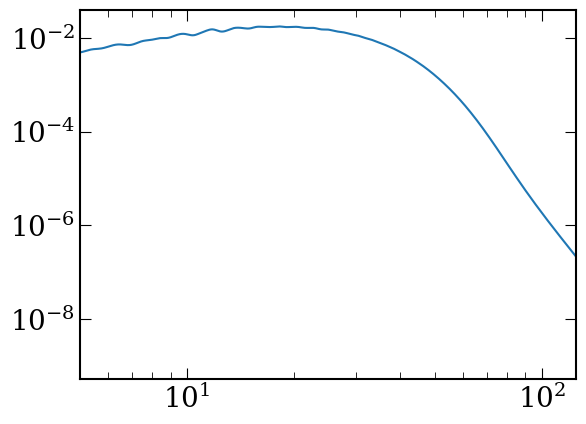

In [46]:
fig, ax = plt.subplots()
ax.plot(freq_GHz_15272, specs_15272['c'])
ax.set(xscale = 'log', yscale = 'log', xlim = (5, 125))
fig

In [47]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=15)
plt.rc('axes', linewidth=1.5)

plt.rc('axes', labelsize=20)   # x/ylabel size
plt.rc('axes', titlesize=22)   # axis title size
plt.rc('xtick', labelsize=20, direction='in', top=True)
plt.rc('ytick', labelsize=20, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=8, pad=4)
plt.rc('xtick.minor', size=5)
plt.rc('ytick.major', size=8)
plt.rc('ytick.minor', size=5)
plt.rc('legend', fontsize=16)


4
4


/tmp/ipykernel_2939043/314624218.py:554: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Figure saved → figs/AME_fullsim_nu2.png


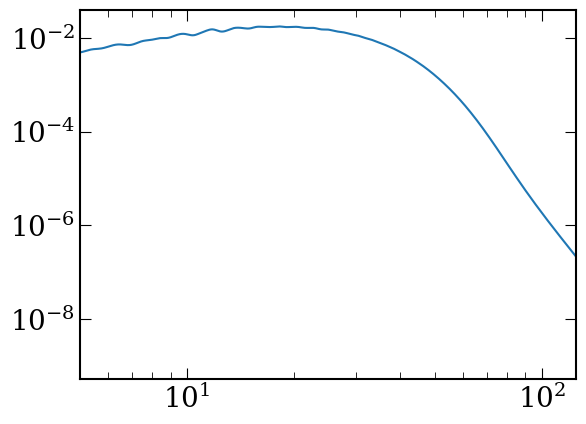

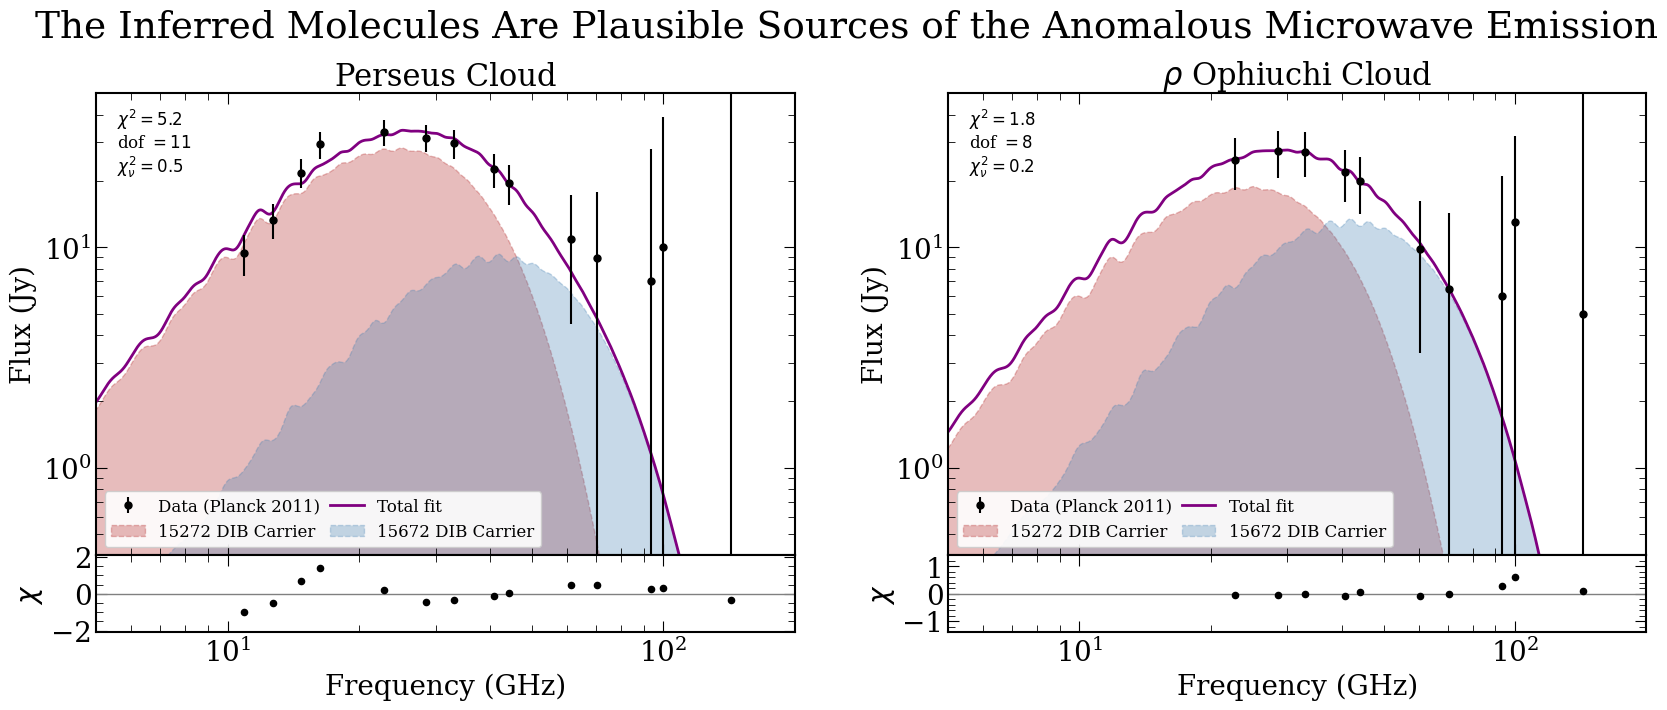

In [48]:
# ── Manual amplitudes ─────────────────────────────────────────────────────────
# Set the four profile amplitudes directly and plot.
f2 = 0
f6 = 0

amp_15272_b = 1.318
amp_15272_a = f2*amp_15272_b
amp_15672_b = 0.252
amp_15672_a = f6*amp_15672_b

manual_amps_perseus = np.array([amp_15272_a, amp_15272_b, amp_15672_a, amp_15672_b])

f2 = 0
f6 = 0

amp_15272_b = 0.88
amp_15272_a = f2*amp_15272_b
amp_15672_b = 0.364
amp_15672_a = f6*amp_15672_b

manual_amps_ophiuchi = np.array([amp_15272_a, amp_15272_b, amp_15672_a, amp_15672_b])

manual_results = {}
profile_labels = ['15272 DIB Carrier', '15272 DIB Carrier', '15672 DIB Carrier', '15672 DIB Carrier']
for ds_name, ds in AME_DATASETS.items():
    if 'Perseus' in ds_name:
        manual_amps = manual_amps_perseus
    if 'Ophiuchi' in ds_name:
        manual_amps = manual_amps_ophiuchi
    M    = build_model_matrix(profiles_GHz, ds['nu'])
    resid = ds['flux'] - M @ manual_amps
    chi2  = float(np.sum((resid / ds['err']) ** 2))
    manual_results[ds_name] = dict(nu=ds['nu'], flux=ds['flux'], err=ds['err'],
                                   amps=manual_amps, chi2=chi2, M_data=M)

# plot_results(profiles_GHz, profile_labels, manual_results, savefig='figs/AME_fullsim.png', fit_mode=fit_mode)
plot_results(profiles_GHz, profile_labels, manual_results, savefig='figs/AME_fullsim_nu2.png', fit_mode=fit_mode)



In [49]:
profile_labels

['15272 DIB Carrier',
 '15272 DIB Carrier',
 '15672 DIB Carrier',
 '15672 DIB Carrier']